"""
Transformer 完整实现 (PyTorch)
参考论文: "Attention Is All You Need" (Vaswani et al., 2017)

架构概览:
  Input → Embedding + Positional Encoding
        → N × Encoder Layer (Self-Attention + FFN)
        → N × Decoder Layer (Masked Self-Attention + Cross-Attention + FFN)
        → Linear + Softmax → Output
"""

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# 1. 多头注意力 (Multi-Head Attention)
class MultiHeadAttention(nn.Module):
	"""
	多头注意力机制

    核心思想:
      将 Q/K/V 投影到 h 个低维子空间，分别计算注意力，再拼接。
      允许模型在不同位置关注不同的表示子空间。

    计算流程:
      Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) · V
      MultiHead = Concat(head_1, ..., head_h) · W_O
	"""
	def __init__(self, hidden_size, num_heads, dropout=0.1):
		super(MultiHeadAttention, self).__init__()
		assert hidden_size % num_heads == 0, "hidden_size 必须能被 num_heads 整除"

		self.hidden_size = hidden_size
		self.num_heads = num_heads
		self._hidden_size = hidden_size // num_heads

		self.W_q = nn.Linear(hidden_size, hidden_size, bias=False)
		self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)
		self.W_v = nn.Linear(hidden_size, hidden_size, bias=False)
		self.W_o = nn.Linear(hidden_size, hidden_size, bias=False)
		self.dropout = nn.Dropout(dropout)

	def split_heads(self, x):
		"""
        将张量拆分为多个头
        输入:  (batch, seq_len, hidden_size)
        输出:  (batch, num_heads, seq_len, _hidden_size)
        """
		batch, seq_len, _ = x.shape
		# 重塑为 (batch, seq_len, num_heads, _hidden_size) 再转置
		x = x.view(batch, seq_len, self.num_heads, self._hidden_size)
		return x.transpose(1,2)  # (batch, num_heads, seq_len, _hidden_size)

	def scaled_dot_product_attention(self, q, k, v, mask = None):
		"""
        缩放点积注意力
        输入形状: (batch, num_heads, seq_len, _hidden_size)
        """
		# 计算注意力分数: QK^T / sqrt(d_k)
		scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self._hidden_size)
		# scores: (batch, num_heads, seq_len_q, seq_len_k)

		# 应用掩码 (padding mask 或 causal mask)
		if mask is not None:
			scores = scores.masked_fill(mask == 0, float('-inf'))

		# Softmax 归一化 → 注意力权重
		attn_weights = F.softmax(scores, dim=-1)
		attn_weights = self.dropout(attn_weights)

		# 加权求和得到输出
		output = torch.matmul(attn_weights, v)
		return output # (batch, num_heads, seq_len_q, _hidden_size)

	def forward(self, q, k, v, mask = None):
		"""
		参数:
		  Q: (batch, seq_len_q, hidden_size)
		  K: (batch, seq_len_k, hidden_size)
		  V: (batch, seq_len_v, hidden_size)  — seq_len_k == seq_len_v
		  mask: 注意力掩码
		返回:
		  output: (batch, seq_len_q, d_model)
		"""
		batch = q.shape[0]

		# 1. 线性投影
		q = self.split_heads(self.W_q(q))  # (batch, h, seq_q, _hidden_size)
		k = self.split_heads(self.W_k(k))  # (batch, h, seq_k, _hidden_size)
		v = self.split_heads(self.W_v(v))  # (batch, h, seq_v, _hidden_size)

		# 2. 缩放点积注意力
		x = self.scaled_dot_product_attention(q, k, v, mask)
		# x: (batch, h, seq_q, _hidden_size)

		# 3. 合并多头: 转置后 reshape
		x = x.transpose(1, 2).contiguous()         # (batch, seq_q, h, _hidden_size)
		x = x.view(batch, -1, self.hidden_size)         # (batch, seq_q, hidden_size)

		# 4. 输出投影
		return self.W_o(x)

In [3]:
# 多头注意力机制案例
multi_attn = MultiHeadAttention(64,4,0.1)
q = torch.randn(200,100,64)
k = torch.randn(200,50,64)
v = torch.randn(200,50,64)

score = multi_attn(q, k, v)

print(score.size())


torch.Size([200, 100, 64])


In [4]:
# 2. 前馈网络 (Position-wise Feed-Forward Network)
class FeedForward(nn.Module):
	"""
	位置前馈网络 (FFN)

    结构: Linear → ReLU → Dropout → Linear
    论文中 d_ff = 4 * hidden_size = 2048
	"""
	def __init__(self, hidden_size, d_ff,  dropout=0.1):
		super(FeedForward, self).__init__()
		self.linear1 = nn.Linear(hidden_size, d_ff)
		self.linear2 = nn.Linear(d_ff, hidden_size)
		self.dropout = nn.Dropout(dropout)

	def forward(self, x):
		# (batch, seq_len, hidden_size) → (batch, seq_len, d_ff) → (batch, seq_len, hidden_size)
		return self.linear2(self.dropout(F.relu(self.linear1(x))))

In [5]:
# 前馈网络案例
ffn = FeedForward(64,256)
x = torch.randn(200,100,64)
y = ffn(x)
print(y.size())


torch.Size([200, 100, 64])


In [6]:
# 3. 位置编码 (Positional Encoding)
class PositionalEncoding(nn.Module):
	"""
	正弦/余弦位置编码 (固定，不可学习)
	PE(pos, 2i)   = sin(pos / 10000^(2i/hidden_size))
	PE(pos, 2i+1) = cos(pos / 10000^(2i/hidden_size))
	作用: 为无序的注意力机制注入位置信息。
	"""
	def __init__(self, hidden_size, max_len = 5000, dropout=0.1):
		super(PositionalEncoding, self).__init__()
		self.dropout = nn.Dropout(dropout)

		# 构造位置编码矩阵 (max_len, hidden_size)
		pe = torch.zeros(max_len, hidden_size)
		position = torch.arange(0, max_len).unsqueeze(1).float()         # (max_len, 1)
		div_term = torch.exp(
			torch.arange(0, hidden_size, 2) * -(math.log(10000.0) / hidden_size)
		)  # (hidden_size/2,)

		pe[:, 0::2] = torch.sin(position * div_term)  # 偶数维度
		pe[:, 1::2] = torch.cos(position * div_term)  # 奇数维度
		pe = pe.unsqueeze(0)  # (1, max_len, d_model) — 方便广播

		# register_buffer: 不参与梯度，但随模型保存/加载
		self.register_buffer('pe', pe)

	def forward(self, x):
		# x: (batch, seq_len, d_model)
		x = x + self.pe[:, :x.size(1), :]
		return self.dropout(x)

torch.Size([200, 16, 16])


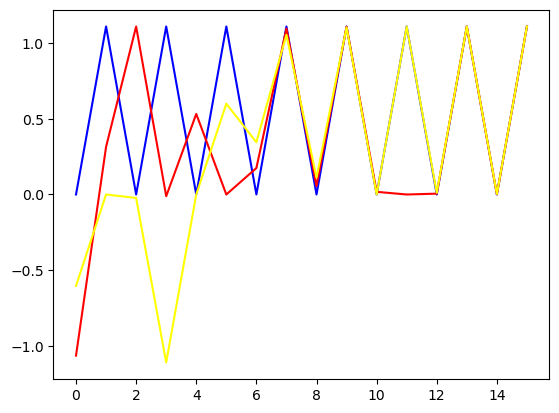

In [7]:
# 位置编码案例
import matplotlib.pyplot as plt
po_encoding = PositionalEncoding(16,16)
x = torch.zeros(200,16,16)
y = po_encoding(x)
print(y.size())
plt.plot(y.numpy()[0][0],color='blue')
plt.plot(y.numpy()[0][5],color='red')
plt.plot(y.numpy()[0][10],color='yellow')
plt.show()

In [8]:
# 4. 编码器层 (Encoder Layer)
class EncoderLayer(nn.Module):
	"""
    单个编码器层
    结构:
      x → Self-Attention → Add & Norm → FFN → Add & Norm → 输出
    """
	def __init__(self, hidden_size, num_heads, d_ff, dropout=0.1):
		super(EncoderLayer, self).__init__()
		self.self_attn = MultiHeadAttention(hidden_size, num_heads, dropout=dropout)
		self.ffn = FeedForward(hidden_size, d_ff, dropout=dropout)
		self.norm1 = nn.LayerNorm(hidden_size)
		self.norm2 = nn.LayerNorm(hidden_size)
		self.dropout = nn.Dropout(dropout)

	def forward(self, x, mask):
        # 子层1: 自注意力 + 残差连接 + 层归一化
		attn_out = self.self_attn(x, x, x, mask)
		x = self.norm1(x + self.dropout(attn_out))

        # 子层2: FFN + 残差连接 + 层归一化
		fnn_out = self.ffn(x)
		x = self.norm2(x + self.dropout(fnn_out))
		return x

In [9]:
# 编码器层案例
enc_layer = EncoderLayer(64,4,256)
x = torch.randn(200,100,64)
y = enc_layer(x, None)
print(y.size())

torch.Size([200, 100, 64])


In [10]:
# 5. 解码器层 (Decoder Layer)
class DecoderLayer(nn.Module):
	"""
    单个解码器层
    结构:
      x → Masked Self-Attention → Add & Norm
        → Cross-Attention (与编码器输出) → Add & Norm
        → FFN → Add & Norm → 输出
    """
	def __init__(self, hidden_size, num_heads, d_ff, dropout=0.1):
		super(DecoderLayer, self).__init__()
		self.self_attn = MultiHeadAttention(hidden_size, num_heads, dropout=dropout)  # 带 causal mask
		self.cross_attn = MultiHeadAttention(hidden_size, num_heads, dropout=dropout)  # 与 encoder 交互
		self.ffn = FeedForward(hidden_size, d_ff, dropout=dropout)

		self.norm1 = nn.LayerNorm(hidden_size)
		self.norm2 = nn.LayerNorm(hidden_size)
		self.norm3 = nn.LayerNorm(hidden_size)
		self.dropout = nn.Dropout(dropout)

	def forward(self, x,enc_output,src_mask,tgt_mask):
		# 子层1: 带掩码的自注意力 (防止看到未来 token)
		self_attn_out = self.self_attn(x, x, x, tgt_mask)
		x = self.norm1(x + self.dropout(self_attn_out))

		# 子层2: 交叉注意力 (Q 来自解码器，K/V 来自编码器)
		cross_attn_out = self.cross_attn(x, enc_output, enc_output, src_mask)
		x = self.norm2(x + self.dropout(cross_attn_out))

		# 子层3: FFN
		ffn_out = self.ffn(x)
		x = self.norm3(x + self.dropout(ffn_out))
		return x

In [11]:
# 解码器层案例
enc_layer = DecoderLayer(64,4,256)
x = torch.randn(200,100,64)
y = enc_layer(x,x,None, None)
print(y.size())

torch.Size([200, 100, 64])


In [12]:
# 6. 编码器 (Encoder)
class Encoder(nn.Module):
	def __init__(self, hidden_size, num_heads, d_ff, num_layers, dropout=0.1):
		super(Encoder, self).__init__()
		self.layers = nn.ModuleList([
			EncoderLayer(hidden_size, num_heads, d_ff, dropout)
			for _ in range(num_layers)
		])
		self.norm = nn.LayerNorm(hidden_size)

	def forward(self, x, mask):
		for layer in self.layers:
			x = layer(x, mask)
		return self.norm(x)

In [13]:
# 编码器案例
enc_layer = Encoder(64,4,256,3)
x = torch.randn(200,100,64)
y = enc_layer(x, None)
print(y.size())

torch.Size([200, 100, 64])


In [14]:
# 7. 解码器 (Decoder)
class Decoder(nn.Module):
	def __init__(self, hidden_size, num_heads, d_ff, num_layers, dropout=0.1):
		super(Decoder, self).__init__()
		self.layers = nn.ModuleList([
			DecoderLayer(hidden_size, num_heads, d_ff, dropout)
			for _ in range(num_layers)
		])
		self.norm = nn.LayerNorm(hidden_size)
	def forward(self, x, enc_output, src_mask, tgt_mask):
		for layer in self.layers:
			x = layer(x, enc_output, src_mask, tgt_mask)
		return self.norm(x)

In [15]:
# 解码器案例
enc_layer = Decoder(64,4,256,3)
x = torch.randn(200,100,64)
y = enc_layer(x,x,None, None)
print(y.size())

torch.Size([200, 100, 64])


In [16]:
class Transformer(nn.Module):
	"""
    完整 Transformer (Encoder-Decoder 架构)

    论文默认超参数:
      d_model=512, num_heads=8, num_layers=6, d_ff=2048, dropout=0.1

    参数:
      src_vocab_size: 源语言词汇表大小
      tgt_vocab_size: 目标语言词汇表大小
      d_model:        模型维度
      num_heads:      注意力头数
      num_layers:     编码器/解码器层数
      d_ff:           前馈网络隐层维度
      max_len:        最大序列长度
      dropout:        Dropout 概率
    """
	def __init__(self, src_vocab_size, tgt_vocab_size, hidden_size = 512, num_heads = 8, num_layers = 6, d_ff = 2048, max_len = 5000, dropout=0.1):
		super(Transformer, self).__init__()

		# 词嵌入
		self.src_embedding = nn.Embedding(src_vocab_size, hidden_size)
		self.tgt_embedding = nn.Embedding(tgt_vocab_size, hidden_size)

		# 位置编码
		self.pos_encoding = PositionalEncoding(hidden_size, max_len = max_len, dropout=dropout)

		# 编码器 & 解码器
		self.encoder = Encoder(hidden_size, num_heads, d_ff, num_layers, dropout=dropout)
		self.decoder = Decoder(hidden_size, num_heads, d_ff, num_layers, dropout=dropout)

		# 输出投影层 (d_model → tgt_vocab_size)
		self.output_proj = nn.Linear(hidden_size, tgt_vocab_size, bias=False)

		self.hidden_size = hidden_size

		# 参数初始化 (Xavier uniform)
		self._init_weights()

	def _init_weights(self):
		for p in self.parameters():
			if p.dim() > 1:
				nn.init.xavier_uniform_(p)

	def make_src_mask(self, src, pad_idx=0):
		"""
        源序列 padding 掩码
        pad 位置为 0，其余为 1
        输出: (batch, 1, 1, src_len) — 广播到 (batch, heads, seq_q, seq_k)
        """
		return (src != pad_idx).unsqueeze(1).unsqueeze(2)

	def make_tgt_mask(self,tgt,pad_idx=0):
		"""
        目标序列掩码 = padding mask AND causal mask

        causal mask (下三角矩阵) 确保位置 i 只能看到 ≤ i 的 token。
        """
		tgt_len = tgt.shape[1]
		# Padding mask: (batch, 1, 1, tgt_len)
		tgt_pad_mask = (tgt != pad_idx).unsqueeze(1).unsqueeze(2)
		# Causal mask: (1, 1, tgt_len, tgt_len)
		tgt_causal_mask = torch.tril(torch.ones(tgt_len, tgt_len, device=tgt.device)).unsqueeze(0).unsqueeze(0)
		# 合并两种掩码
		return tgt_pad_mask & tgt_causal_mask.bool()

	def forward(self, src, tgt, src_pad_idx = 0, tgt_pad_idx = 0):
		"""
        参数:
          src: (batch, src_len)  — 源序列 token ids
          tgt: (batch, tgt_len)  — 目标序列 token ids (训练时 teacher forcing)
        返回:
          logits: (batch, tgt_len, tgt_vocab_size)
        """
		src_mask = self.make_src_mask(src,src_pad_idx)
		tgt_mask = self.make_tgt_mask(tgt,tgt_pad_idx)

		# 嵌入 + 位置编码 (乘以 sqrt(d_model) 缩放，论文 §3.4)
		src_emb = self.pos_encoding(self.src_embedding(src) * math.sqrt(self.hidden_size))
		tgt_emb = self.pos_encoding(self.tgt_embedding(tgt) * math.sqrt(self.hidden_size))

		# 编码器
		enc_out = self.encoder(src_emb, src_mask)

		# 解码器
		dec_out = self.decoder(tgt_emb, enc_out, src_mask, tgt_mask)

		logits = self.output_proj(dec_out)
		return logits

In [17]:
# Transformer案例
tf = Transformer(100,100,64,4,3,256,100)
x = torch.randint(0,100,size=(200,100))
y = torch.randint(0,100,size=(200,100))
output = tf(x,x,0,0)
print(output.shape)

torch.Size([200, 100, 100])


In [18]:
# 9. 快速验证
if __name__ == "__main__":
    # 超参数 (小型测试配置)
    SRC_VOCAB = 1000
    TGT_VOCAB = 1000
    D_MODEL   = 64
    N_HEADS   = 4
    N_LAYERS  = 2
    D_FF      = 256
    BATCH     = 2
    SRC_LEN   = 20
    TGT_LEN   = 15

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}\n")

    # 初始化模型
    model = Transformer(
        src_vocab_size=SRC_VOCAB,
        tgt_vocab_size=TGT_VOCAB,
        hidden_size=D_MODEL,
        num_heads=N_HEADS,
        num_layers=N_LAYERS,
        d_ff=D_FF,
    ).to(device)

    # 打印参数量
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"模型参数总量: {total_params:,}")

    # 生成随机输入 (包含 padding token=0)
    src = torch.randint(1, SRC_VOCAB, (BATCH, SRC_LEN)).to(device)
    tgt = torch.randint(1, TGT_VOCAB, (BATCH, TGT_LEN)).to(device)

    # 前向传播
    model.eval()
    with torch.no_grad():
        logits = model(src, tgt)

    print(f"输入 src 形状:    {src.shape}")
    print(f"输入 tgt 形状:    {tgt.shape}")
    print(f"输出 logits 形状: {logits.shape}")
    # 预期: (BATCH, TGT_LEN, TGT_VOCAB) = (2, 15, 10000)

    # ---- 简单训练示例 ----
    print("\n--- 简单训练示例 (1 步) ---")
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
    criterion = nn.CrossEntropyLoss(ignore_index=0)  # 忽略 padding token

    # 目标: 将 tgt 右移一位作为 label (teacher forcing)
    tgt_input  = tgt[:, :-1]   # (batch, TGT_LEN-1)
    tgt_label  = tgt[:, 1:]    # (batch, TGT_LEN-1)

    logits = model(src, tgt_input)         # (batch, TGT_LEN-1, vocab)
    # CrossEntropyLoss 需要 (N, C) 或 (N, C, *) 格式
    loss = criterion(logits.reshape(-1, TGT_VOCAB), tgt_label.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"训练 loss: {loss.item():.4f}")
    print("\n✅ Transformer 构建并运行成功！")

使用设备: cpu

模型参数总量: 424,192
输入 src 形状:    torch.Size([2, 20])
输入 tgt 形状:    torch.Size([2, 15])
输出 logits 形状: torch.Size([2, 15, 1000])

--- 简单训练示例 (1 步) ---
训练 loss: 7.0264

✅ Transformer 构建并运行成功！
